<>:182: SyntaxWarning: invalid escape sequence '\A'
<>:182: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_1563/3076360677.py:182: SyntaxWarning: invalid escape sequence '\A'
  print("\Assignment completed successfully ✔️")


Dataset shape: (700, 9)
   age  ed  employ  address  income  debtinc   creddebt   othdebt  default
0   41   3      17       12     176      9.3  11.359392  5.008608      1.0
1   27   1      10        6      31     17.3   1.362202  4.000798      0.0
2   40   1      15       14      55      5.5   0.856075  2.168925      0.0
3   41   1      15       14     120      2.9   2.658720  0.821280      0.0
4   24   2       2        0      28     17.3   1.787436  3.056564      1.0

Missing values:
age         0
ed          0
employ      0
address     0
income      0
debtinc     0
creddebt    0
othdebt     0
default     0
dtype: int64

Summary statistics:
              age          ed      employ     address      income     debtinc  \
count  700.000000  700.000000  700.000000  700.000000  700.000000  700.000000   
mean    34.860000    1.722857    8.388571    8.278571   45.601429   10.260571   
std      7.997342    0.928206    6.658039    6.824877   36.814226    6.827234   
min     20.000000    1.00

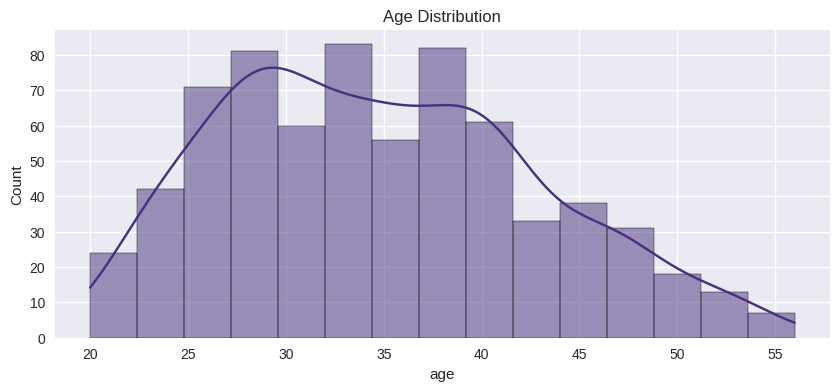

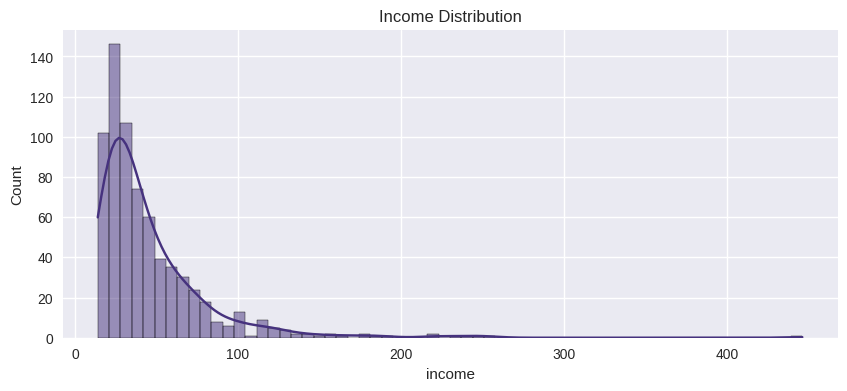

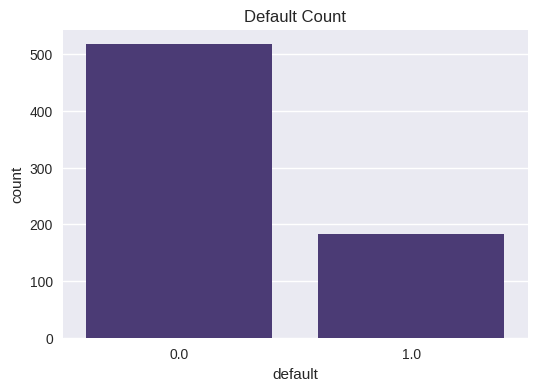

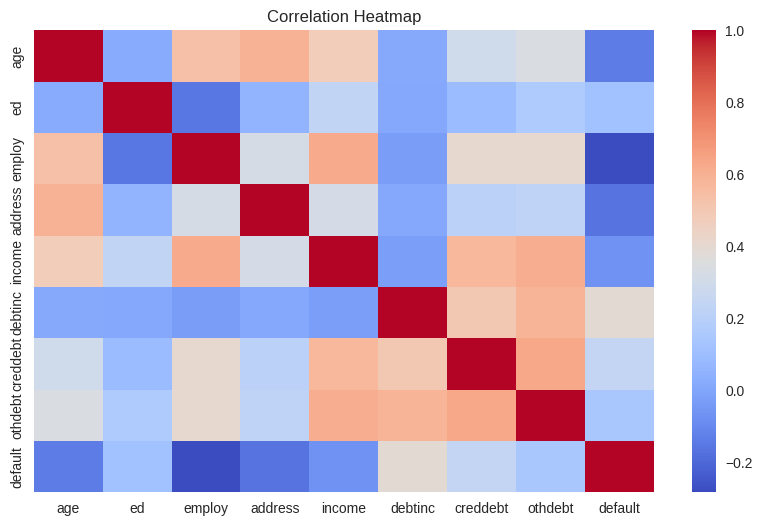


New engineered features added:
   total_debt  debt_to_income
0      16.368           0.093
1       5.363           0.173
2       3.025           0.055
3       3.480           0.029
4       4.844           0.173

Train/Test shapes: (490, 10) (210, 10)

Accuracy: 0.8095238095238095

Confusion Matrix:
[[137  18]
 [ 22  33]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.88      0.87       155
         1.0       0.65      0.60      0.62        55

    accuracy                           0.81       210
   macro avg       0.75      0.74      0.75       210
weighted avg       0.81      0.81      0.81       210



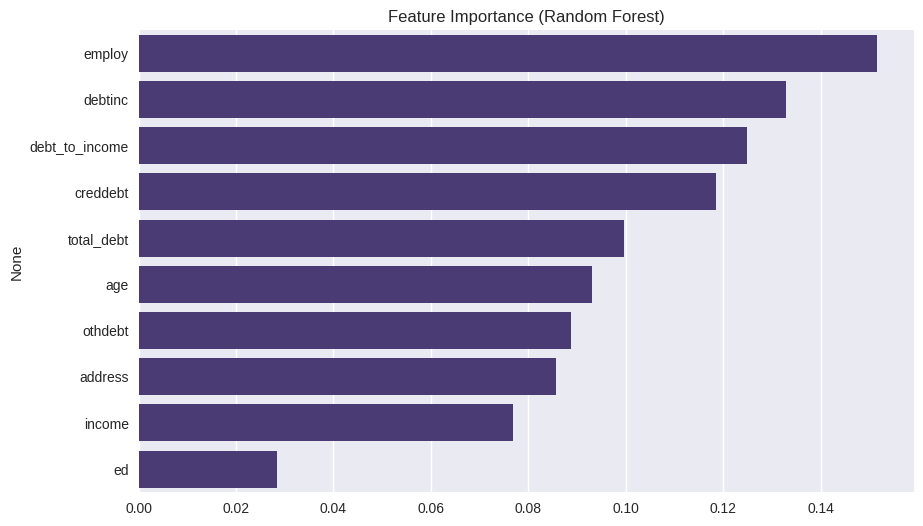


Feature importance:
employ            0.151475
debtinc           0.132908
debt_to_income    0.124884
creddebt          0.118559
total_debt        0.099563
age               0.093040
othdebt           0.088727
address           0.085585
income            0.076837
ed                0.028422
dtype: float64

Generating SHAP beeswarm plot...


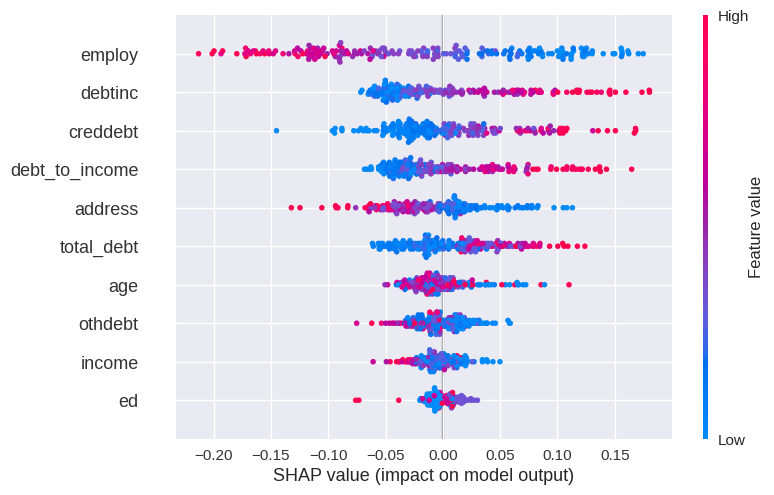


Generating SHAP bar plot...


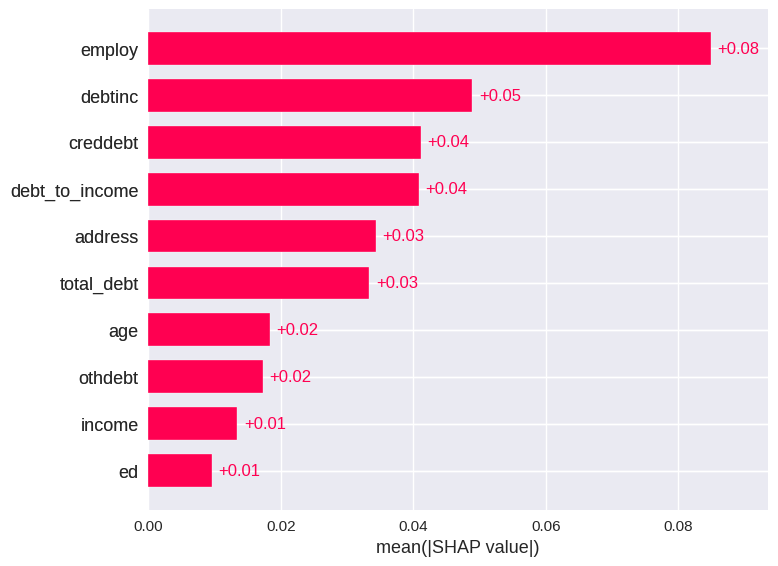


Generating SHAP waterfall plot for first sample...


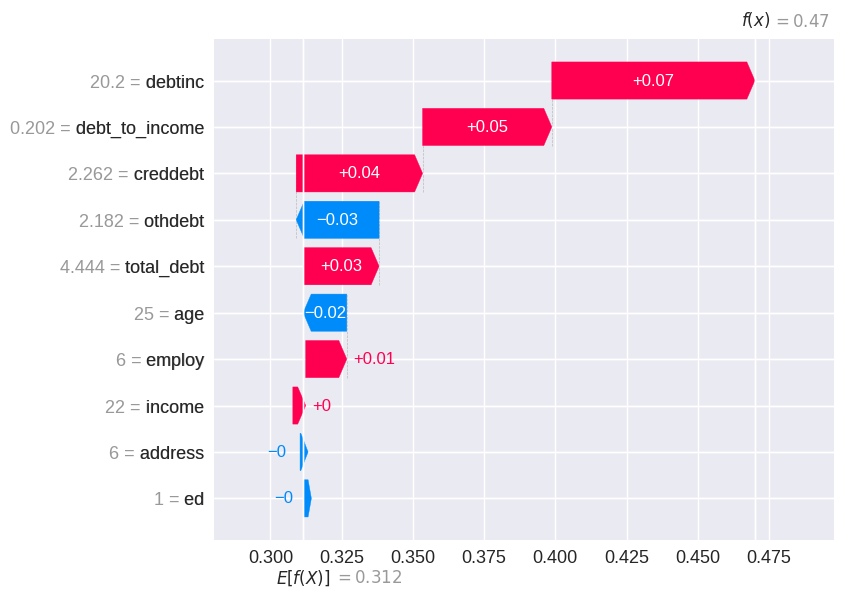


Fairness results by age group:
  age_group  accuracy  default_rate
0      <=25  0.750000      0.500000
1       46+  0.761905      0.285714
2     36-45  0.833333      0.138889
3     26-35  0.814433      0.298969


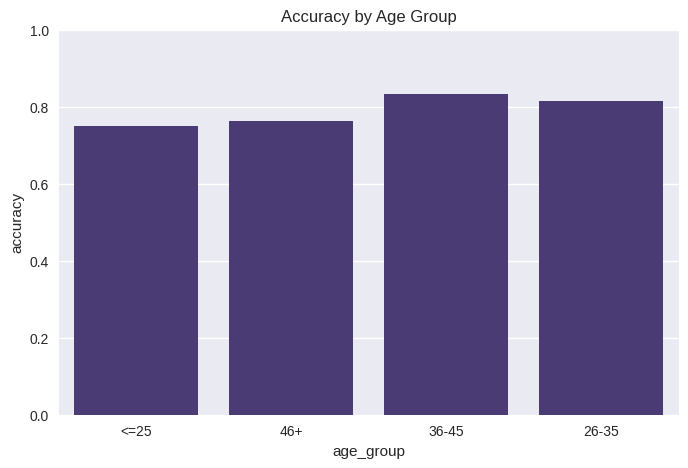

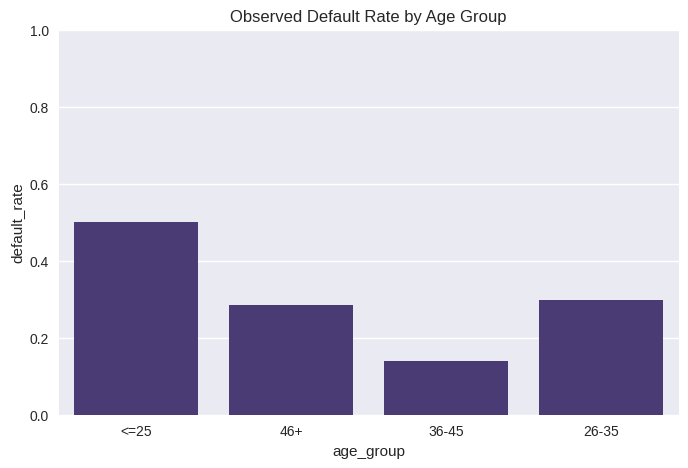

\Assignment completed successfully ✔️


In [7]:
# =========================================================
# Loan Default Prediction + SHAP + Fairness
# Using NEW SHAP API (binary-class fix)
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import shap

plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")

# =========================================================
# 1. LOAD DATA + CLEANING
# =========================================================

df = pd.read_csv("bank-loan.csv")

# Drop rows where target is missing (your file is truncated at the end)
df = df.dropna(subset=["default"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print(df.head())

print("\nMissing values:")
print(df.isna().sum())

# =========================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# =========================================================

print("\nSummary statistics:")
print(df.describe())

plt.figure(figsize=(10,4))
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.show()

plt.figure(figsize=(10,4))
sns.histplot(df["income"], kde=True)
plt.title("Income Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="default", data=df)
plt.title("Default Count")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# =========================================================
# 3. FEATURE ENGINEERING
# =========================================================

df["total_debt"] = df["creddebt"] + df["othdebt"]
df["debt_to_income"] = df["total_debt"] / df["income"].replace(0, np.nan)
df["debt_to_income"] = df["debt_to_income"].fillna(0)

print("\nNew engineered features added:")
print(df[["total_debt", "debt_to_income"]].head())

# =========================================================
# 4. TRAIN/TEST SPLIT
# =========================================================

target = "default"
feature_cols = [c for c in df.columns if c not in ["default", "age_group"]]

X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("\nTrain/Test shapes:", X_train.shape, X_test.shape)

# =========================================================
# 5. MODEL TRAINING (Random Forest)
# =========================================================

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================================================
# 6. FEATURE IMPORTANCE
# =========================================================

importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance (Random Forest)")
plt.show()

print("\nFeature importance:")
print(feat_imp)

# =========================================================
# 7. SHAP EXPLAINABILITY (NEW API — FIXED FOR BINARY CLASSIFICATION)
# =========================================================

# New SHAP API automatically handles feature alignment
explainer = shap.Explainer(rf, X_train)
shap_values = explainer(X_test)   # shape: (n_samples, n_features, 2)

# Select SHAP values for class 1 (default = 1)
shap_class1 = shap_values[..., 1]

print("\nGenerating SHAP beeswarm plot...")
shap.plots.beeswarm(shap_class1)

print("\nGenerating SHAP bar plot...")
shap.plots.bar(shap_class1)

print("\nGenerating SHAP waterfall plot for first sample...")
shap.plots.waterfall(shap_class1[0])

# =========================================================
# 8. FAIRNESS ANALYSIS (Age Groups)
# =========================================================

df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 25, 35, 45, 100],
    labels=["<=25", "26-35", "36-45", "46+"]
)

age_group_test = df["age_group"].iloc[X_test.index]

fairness_results = []
for group in age_group_test.unique():
    mask = age_group_test == group
    acc = accuracy_score(y_test[mask], y_pred[mask])
    default_rate = y_test[mask].mean()
    fairness_results.append({
        "age_group": group,
        "accuracy": acc,
        "default_rate": default_rate
    })

fairness_df = pd.DataFrame(fairness_results)
print("\nFairness results by age group:")
print(fairness_df)

plt.figure(figsize=(8,5))
sns.barplot(data=fairness_df, x="age_group", y="accuracy")
plt.title("Accuracy by Age Group")
plt.ylim(0,1)
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=fairness_df, x="age_group", y="default_rate")
plt.title("Observed Default Rate by Age Group")
plt.ylim(0,1)
plt.show()

print("\Assignment completed successfully ✔️")